In [1]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, random_split
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
import numpy as np

# Datayı Okuma ve Analiz Etme

In [7]:
train_dataset = pd.read_csv("kdd_train.csv")
test_dataset = pd.read_csv("kdd_test.csv")

In [8]:
train_dataset.columns, test_dataset.columns

(Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
        'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
        'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
        'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
        'num_access_files', 'num_outbound_cmds', 'is_host_login',
        'is_guest_login', 'count', 'srv_count', 'serror_rate',
        'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
        'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
        'dst_host_srv_count', 'dst_host_same_srv_rate',
        'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
        'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
        'dst_host_srv_rerror_rate', 'labels'],
       dtype='object'),
 Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
        'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',


In [9]:
X_train = train_dataset.drop('labels', axis = 1)
y_train = train_dataset['labels']
X_test = test_dataset.drop('labels', axis = 1)
y_test = test_dataset['labels']

In [10]:
X_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,150,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00
1,0,udp,other,SF,146,0,0,0,0,0,...,255,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00
2,0,tcp,private,S0,0,0,0,0,0,0,...,255,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00
3,0,tcp,http,SF,232,8153,0,0,0,0,...,30,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [11]:
print(f"Length of X_train is {X_train.shape}")
print(f"Length of y_train is {y_train.shape}")
print(f"Length of X_test is {X_test.shape}")
print(f"Length of y_test is {y_test.shape}")

Length of X_train is (125973, 41)
Length of y_train is (125973,)
Length of X_test is (22544, 41)
Length of y_test is (22544,)


In [12]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [13]:
y_train.info()

<class 'pandas.core.series.Series'>
RangeIndex: 125973 entries, 0 to 125972
Series name: labels
Non-Null Count   Dtype 
--------------   ----- 
125973 non-null  object
dtypes: object(1)
memory usage: 984.3+ KB


Buradan gördüğümüz üzere train veri setinde bulunan 40 featuresdan 3 tanesi object yani kategorik diğeri geriye kalan 37 tanesi ise numerik değişken. Bu 3 değer üzerinde encoding işlemi yapmamız gerekiyor.

Aynı şekilde y_train içerisinde bulunan labels özelliği de kategorik değişken olarak geçiyor.

In [14]:
X_train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


labels
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


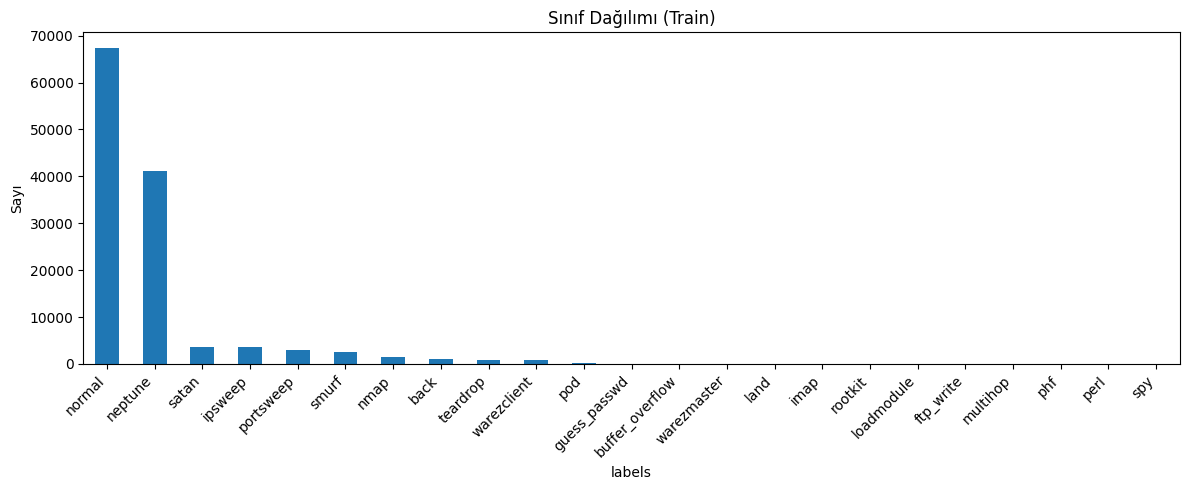

In [15]:
# Sınıf dağılımını inceleyelim
print(y_train.value_counts())
plt.figure(figsize=(12, 5))
y_train.value_counts().plot(kind='bar')
plt.title('Sınıf Dağılımı (Train)')
plt.ylabel('Sayı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [16]:
# Null değerleri kontrol et
print("=== X_train Null Değerler ===")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])
print(f"\nToplam null (X_train): {X_train.isnull().sum().sum()}")

print("\n=== X_test Null Değerler ===")
print(X_test.isnull().sum()[X_test.isnull().sum() > 0])
print(f"\nToplam null (X_test): {X_test.isnull().sum().sum()}")

print("\n=== y_train Null ===")
print(f"Toplam null: {y_train.isnull().sum()}")

print("\n=== y_test Null ===")
print(f"Toplam null: {y_test.isnull().sum()}")


=== X_train Null Değerler ===
Series([], dtype: int64)

Toplam null (X_train): 0

=== X_test Null Değerler ===
Series([], dtype: int64)

Toplam null (X_test): 0

=== y_train Null ===
Toplam null: 0

=== y_test Null ===
Toplam null: 0


#Encoding

In [17]:
categorical = [col for col in X_train if X_train[col].dtype == 'O']
numerical = [col for col in X_train if X_train[col].dtype != 'O']
categorical

['protocol_type', 'service', 'flag']

In [18]:
for col in categorical:
    print(f"\n=== {col} ===")
    print(f"Benzersiz değer sayısı: {X_train[col].nunique()}")
    print(f"Değerler: {X_train[col].unique()}")

print(f"\n=== Labels ===")
print(f"Benzersiz değer sayısı: {y_train.nunique()}")
print(f"Değerler: {y_train.unique()}")




=== protocol_type ===
Benzersiz değer sayısı: 3
Değerler: ['tcp' 'udp' 'icmp']

=== service ===
Benzersiz değer sayısı: 70
Değerler: ['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

=== flag ===
Benzersiz değer sayısı: 11
Değerler: ['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']

=== Labels ===
Benzersiz değer sayısı: 23
Değerler: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 

In [19]:
# Kategorik sütunları LabelEncoder ile encode et
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

# Train + Test birlikte fit et (tüm kategorileri görsün)
le_protocol.fit(pd.concat([X_train['protocol_type'], X_test['protocol_type']]))
le_service.fit(pd.concat([X_train['service'], X_test['service']]))
le_flag.fit(pd.concat([X_train['flag'], X_test['flag']]))

# Transform uygula
X_train['protocol_type'] = le_protocol.transform(X_train['protocol_type'])
X_train['service'] = le_service.transform(X_train['service'])
X_train['flag'] = le_flag.transform(X_train['flag'])

X_test['protocol_type'] = le_protocol.transform(X_test['protocol_type'])
X_test['service'] = le_service.transform(X_test['service'])
X_test['flag'] = le_flag.transform(X_test['flag'])

# Hedef değişkeni encode et
le_labels = LabelEncoder()
le_labels.fit(pd.concat([y_train, y_test]))
y_train_encoded = le_labels.transform(y_train)
y_test_encoded = le_labels.transform(y_test)

In [20]:
num_classes = len(le_labels.classes_)
print("Encoding tamamlandı!")
print(f"\nSınıf sayısı: {num_classes}")
print(f"Sınıflar: {list(le_labels.classes_)}")
print(f"\nX_train dtypes:\n{X_train.dtypes}")


Encoding tamamlandı!

Sınıf sayısı: 37
Sınıflar: ['apache2', 'back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'httptunnel', 'imap', 'ipsweep', 'land', 'loadmodule', 'mailbomb', 'mscan', 'multihop', 'named', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'processtable', 'ps', 'rootkit', 'saint', 'satan', 'sendmail', 'smurf', 'snmpgetattack', 'snmpguess', 'spy', 'teardrop', 'warezclient', 'warezmaster', 'xlock', 'xsnoop', 'xterm']

X_train dtypes:
duration                         int64
protocol_type                    int64
service                          int64
flag                             int64
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell         

# Scaling

In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (125973, 41)
X_test_scaled shape: (22544, 41)


#PyTorch DataLoader Oluşturma

In [22]:
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float).unsqueeze(dim = 1)
y_train_tensor = torch.tensor(y_train_encoded, dtype = torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float).unsqueeze(dim = 1)
y_test_tensor = torch.tensor(y_test_encoded, dtype = torch.long)

In [23]:
full_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_ds, val_ds = random_split(full_train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

In [24]:
BATCH_SIZE = 256
train_loader = DataLoader(
    dataset = train_ds,
    batch_size = BATCH_SIZE,
    shuffle = True
)
val_loader = DataLoader(
    dataset = val_ds,
    batch_size = BATCH_SIZE,
    shuffle = False
)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

In [25]:
num_features = X_train_scaled.shape[1]
print(f"Feature sayısı: {num_features}")
print(f"Sınıf sayısı: {num_classes}")
print(f"Input tensor shape: {X_train_tensor.shape}")  # (N, 1, 41)
print(f"\nTrain: {len(train_ds)} | Validation: {len(val_ds)} | Test: {len(test_dataset)}")

Feature sayısı: 41
Sınıf sayısı: 37
Input tensor shape: torch.Size([125973, 1, 41])

Train: 100778 | Validation: 25195 | Test: 22544


#CNN Modeli

In [26]:
class CNN_IDS(nn.Module):
    def __init__(self, num_features, num_classes):
        super(CNN_IDS, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2)
        )

        # MaxPool sonrası boyut: num_features // 2
        conv_out_size = 128 * (num_features // 2)

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(conv_out_size, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Model oluştur
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model = CNN_IDS(num_features, num_classes).to(device)
print(f"Cihaz: {device}")
print(cnn_model)


Cihaz: cuda
CNN_IDS(
  (conv_layers): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=37, bias=True)
  )
)


In [27]:
def train_model(model, train_loader, val_loader, epochs=30, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }

    for epoch in range(epochs):
        # === TRAIN ===
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)

        # === VALIDATION ===
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                val_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == y_batch).sum().item()
                val_total += y_batch.size(0)

        # Epoch sonuçlarını kaydet
        epoch_train_loss = train_loss / train_total
        epoch_val_loss = val_loss / val_total
        epoch_train_acc = train_correct / train_total
        epoch_val_acc = val_correct / val_total

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | "
                  f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    return history


In [28]:
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=30, lr=0.001)

Epoch [5/30] | Train Loss: 0.0207 | Train Acc: 0.9936 | Val Loss: 0.0235 | Val Acc: 0.9932
Epoch [10/30] | Train Loss: 0.0168 | Train Acc: 0.9949 | Val Loss: 0.0204 | Val Acc: 0.9951
Epoch [15/30] | Train Loss: 0.0129 | Train Acc: 0.9955 | Val Loss: 0.0264 | Val Acc: 0.9926
Epoch [20/30] | Train Loss: 0.0114 | Train Acc: 0.9963 | Val Loss: 0.0166 | Val Acc: 0.9958
Epoch [25/30] | Train Loss: 0.0102 | Train Acc: 0.9963 | Val Loss: 0.0160 | Val Acc: 0.9959
Epoch [30/30] | Train Loss: 0.0100 | Train Acc: 0.9967 | Val Loss: 0.0159 | Val Acc: 0.9965


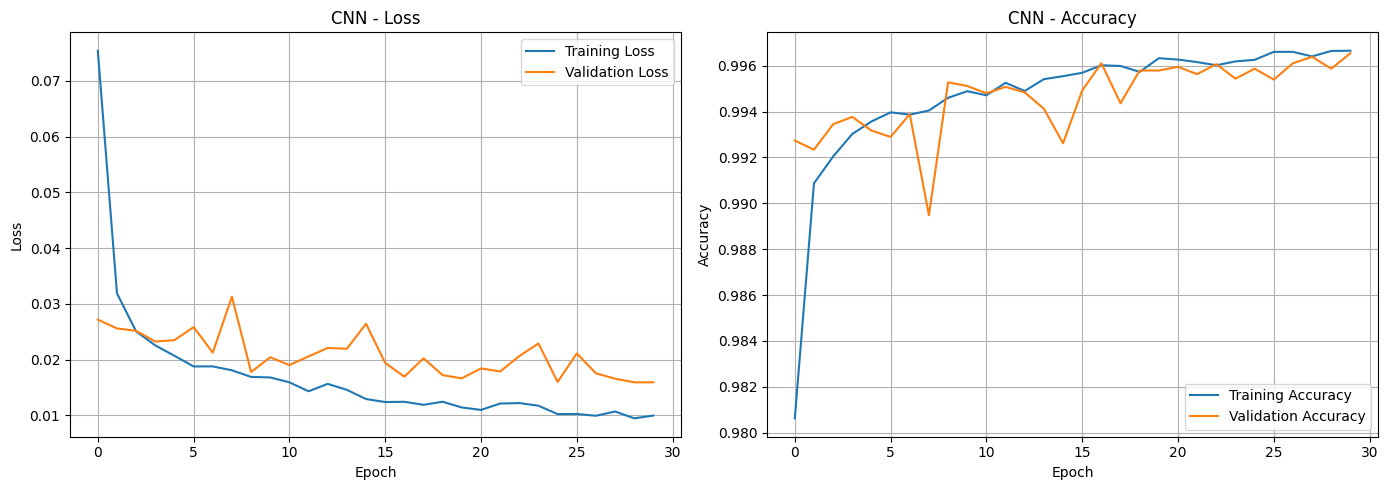

In [29]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Grafiği
    axes[0].plot(history['train_loss'], label='Training Loss')
    axes[0].plot(history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Accuracy Grafiği
    axes[1].plot(history['train_acc'], label='Training Accuracy')
    axes[1].plot(history['val_acc'], label='Validation Accuracy')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history(cnn_history, 'CNN')


#Autoencoder Model

In [30]:
class Autoencoder(nn.Module):
    def __init__(self, num_features):
        super(Autoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, num_features)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def encode(self, x):
        return self.encoder(x)

autoencoder = Autoencoder(num_features).to(device)
print(autoencoder)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=41, bias=True)
  )
)


In [31]:
# Autoencoder için DataLoader (2D veri, unsqueeze yok)
X_train_2d = torch.FloatTensor(X_train_scaled)
ae_dataset = TensorDataset(X_train_2d, X_train_2d)  # input = output (reconstruction)

ae_train_size = int(0.8 * len(ae_dataset))
ae_val_size = len(ae_dataset) - ae_train_size
ae_train_ds, ae_val_ds = random_split(ae_dataset, [ae_train_size, ae_val_size],
                                       generator=torch.Generator().manual_seed(42))

ae_train_loader = DataLoader(ae_train_ds, batch_size=BATCH_SIZE, shuffle=True)
ae_val_loader = DataLoader(ae_val_ds, batch_size=BATCH_SIZE, shuffle=False)

# Eğitim
ae_criterion = nn.MSELoss()
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.001)

ae_history = {'train_loss': [], 'val_loss': []}

print("Autoencoder Eğitimi Başlıyor...")
AE_EPOCHS = 30

for epoch in range(AE_EPOCHS):
    # Train
    autoencoder.train()
    train_loss = 0
    for X_batch, _ in ae_train_loader:
        X_batch = X_batch.to(device)
        ae_optimizer.zero_grad()
        output = autoencoder(X_batch)
        loss = ae_criterion(output, X_batch)
        loss.backward()
        ae_optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    # Validation
    autoencoder.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, _ in ae_val_loader:
            X_batch = X_batch.to(device)
            output = autoencoder(X_batch)
            loss = ae_criterion(output, X_batch)
            val_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = train_loss / len(ae_train_ds)
    epoch_val_loss = val_loss / len(ae_val_ds)
    ae_history['train_loss'].append(epoch_train_loss)
    ae_history['val_loss'].append(epoch_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{AE_EPOCHS}] | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")


Autoencoder Eğitimi Başlıyor...
Epoch [5/30] | Train Loss: 0.096254 | Val Loss: 0.254654
Epoch [10/30] | Train Loss: 0.038061 | Val Loss: 0.127225
Epoch [15/30] | Train Loss: 0.042864 | Val Loss: 0.113353
Epoch [20/30] | Train Loss: 0.044287 | Val Loss: 0.083243
Epoch [25/30] | Train Loss: 0.016440 | Val Loss: 0.090647
Epoch [30/30] | Train Loss: 0.016740 | Val Loss: 0.060076


In [32]:
class AE_CNN(nn.Module):
    def __init__(self, encoder, num_classes):
        super(AE_CNN, self).__init__()

        # Encoder'ı dondur
        self.encoder = encoder
        for param in self.encoder.parameters():
            param.requires_grad = False

        # CNN sınıflandırıcı (encoder çıktısı 32 boyutlu)
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),

            nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.squeeze(1)          # (batch, 1, 41) -> (batch, 41)
        x = self.encoder(x)       # (batch, 32)
        x = x.unsqueeze(1)        # (batch, 1, 32) -> CNN için kanal ekle
        x = self.conv_layers(x)   # Conv1d işlemleri
        x = self.fc_layers(x)     # Sınıflandırma
        return x

ae_cnn_model = AE_CNN(autoencoder.encoder, num_classes).to(device)
print(ae_cnn_model)


AE_CNN(
  (encoder): Sequential(
    (0): Linear(in_features=41, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (conv_layers): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=37, bias=True)
  )
)


In [33]:
ae_cnn_history = train_model(ae_cnn_model, train_loader, val_loader, epochs=30, lr=0.001)


Epoch [5/30] | Train Loss: 0.0259 | Train Acc: 0.9921 | Val Loss: 0.0252 | Val Acc: 0.9933
Epoch [10/30] | Train Loss: 0.0194 | Train Acc: 0.9941 | Val Loss: 0.0230 | Val Acc: 0.9942
Epoch [15/30] | Train Loss: 0.0166 | Train Acc: 0.9947 | Val Loss: 0.0225 | Val Acc: 0.9944
Epoch [20/30] | Train Loss: 0.0141 | Train Acc: 0.9955 | Val Loss: 0.0239 | Val Acc: 0.9944
Epoch [25/30] | Train Loss: 0.0132 | Train Acc: 0.9960 | Val Loss: 0.0254 | Val Acc: 0.9943
Epoch [30/30] | Train Loss: 0.0124 | Train Acc: 0.9960 | Val Loss: 0.0226 | Val Acc: 0.9956


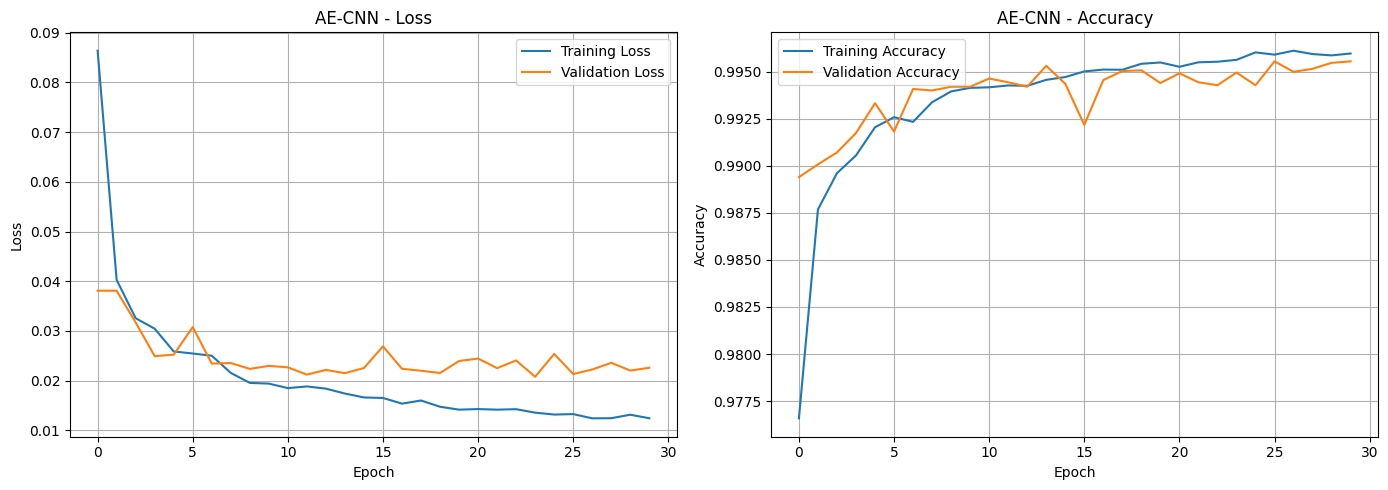

In [34]:
plot_history(ae_cnn_history, 'AE-CNN')

#Test Değerlendirme

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Metrikler
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"\n{'='*50}")
    print(f" {model_name} - Test Sonuçları")
    print(f"{'='*50}")
    print(f" Accuracy:  {acc:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall:    {rec:.4f}")
    print(f" F1-Score:  {f1:.4f}")
    print(f"{'='*50}")

    return all_preds, all_labels, {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}


In [36]:
cnn_preds, cnn_labels, cnn_metrics = evaluate_model(cnn_model, test_loader, "CNN")
ae_cnn_preds, ae_cnn_labels, ae_cnn_metrics = evaluate_model(ae_cnn_model, test_loader, "AE-CNN")


 CNN - Test Sonuçları
 Accuracy:  0.9108
 Precision: 0.8704
 Recall:    0.9108
 F1-Score:  0.8735

 AE-CNN - Test Sonuçları
 Accuracy:  0.9092
 Precision: 0.8690
 Recall:    0.9092
 F1-Score:  0.8722


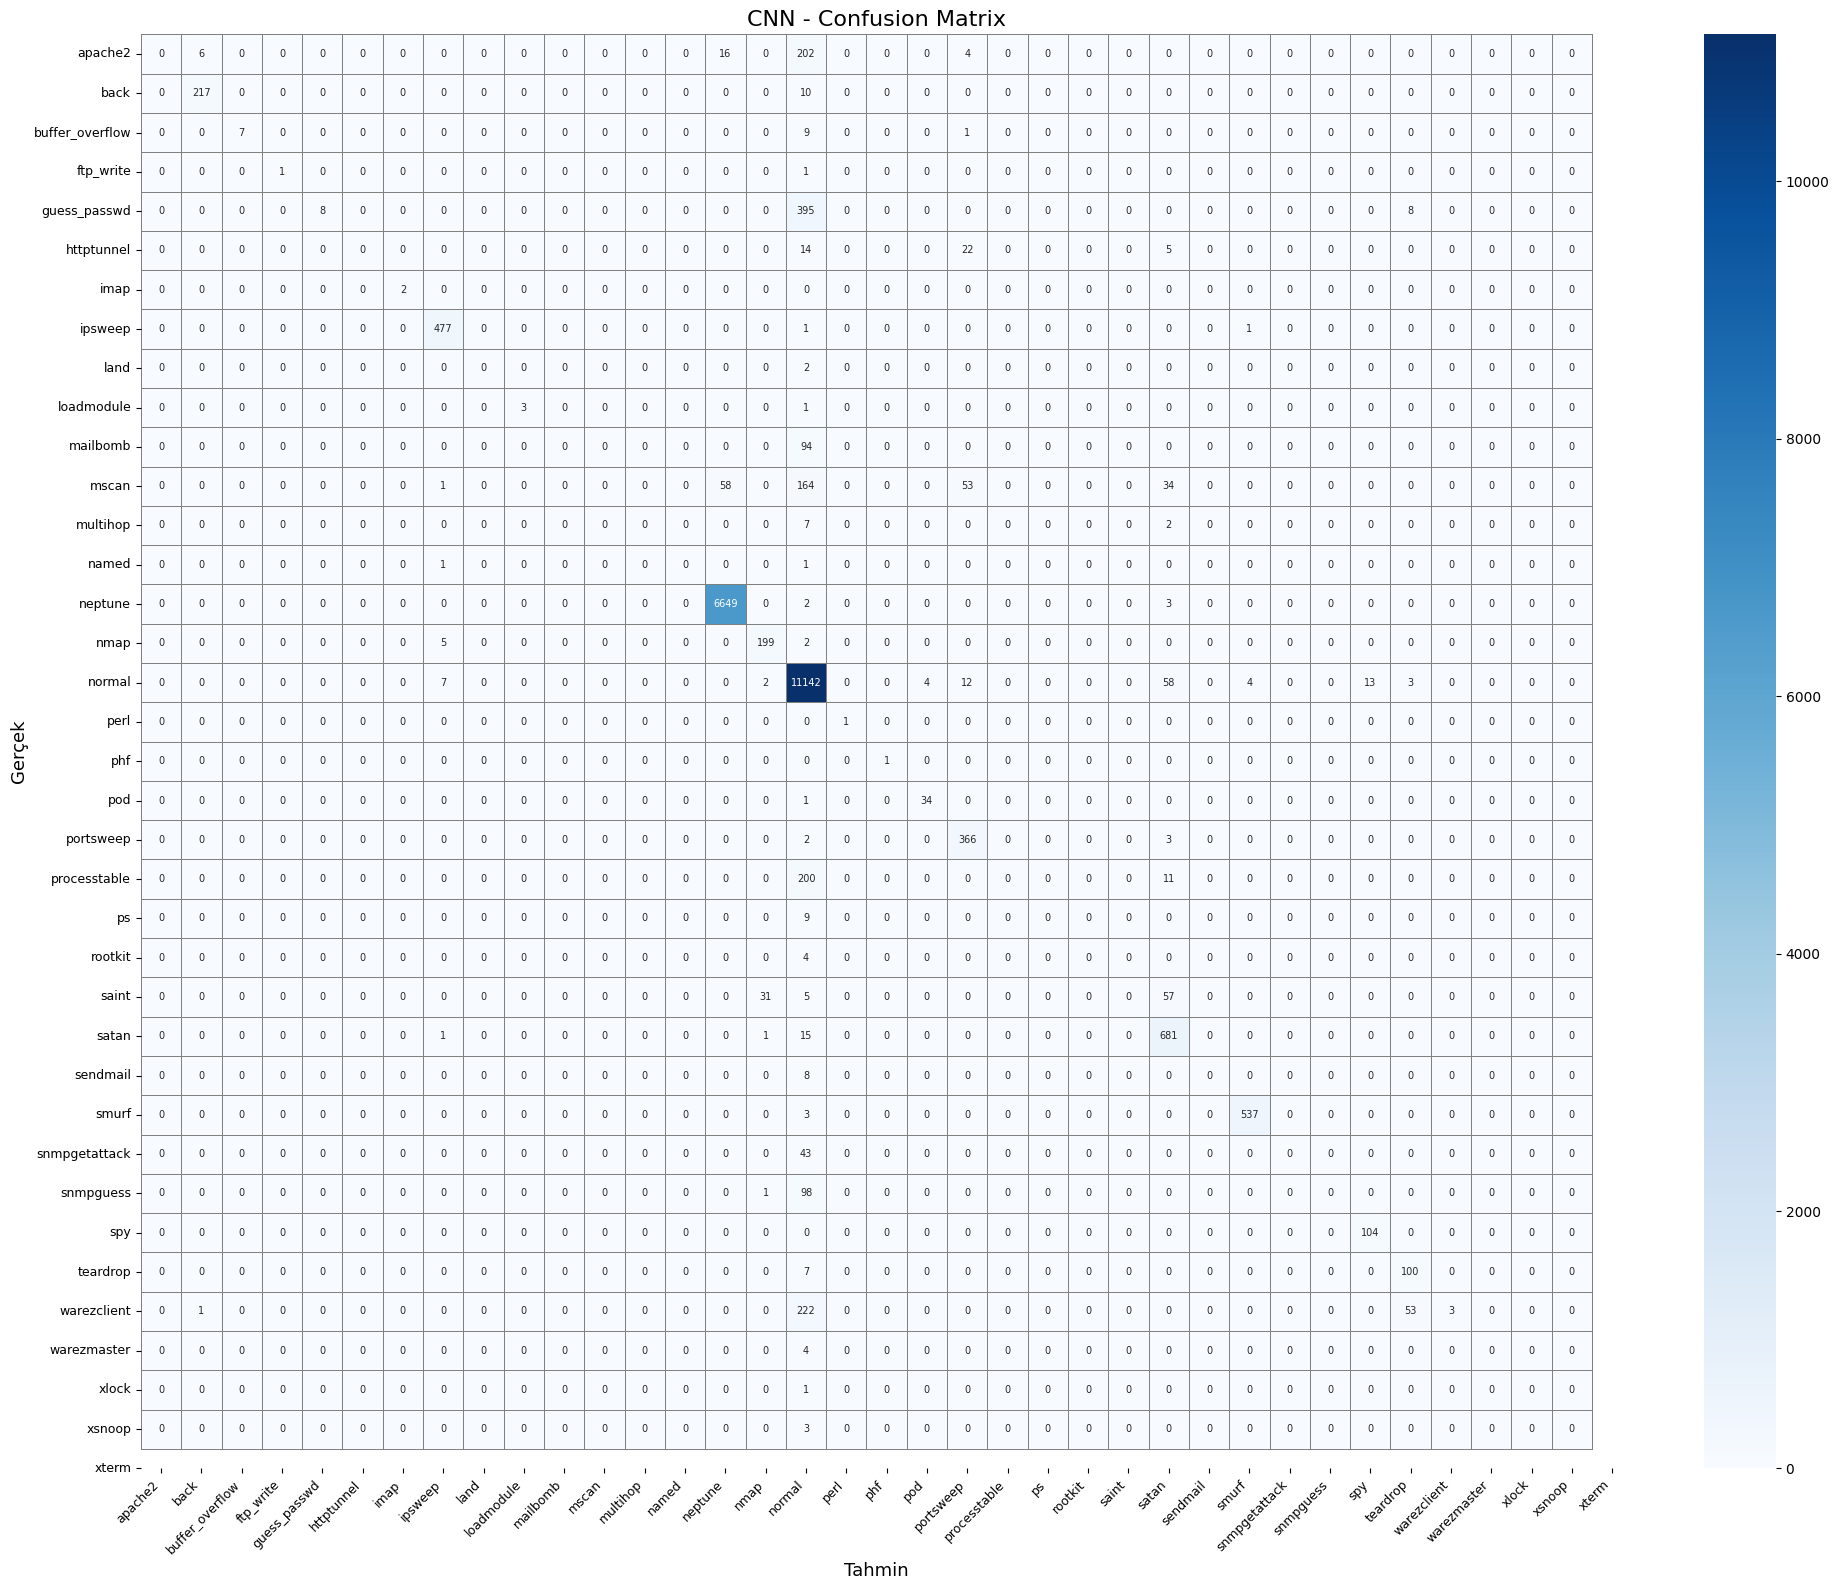

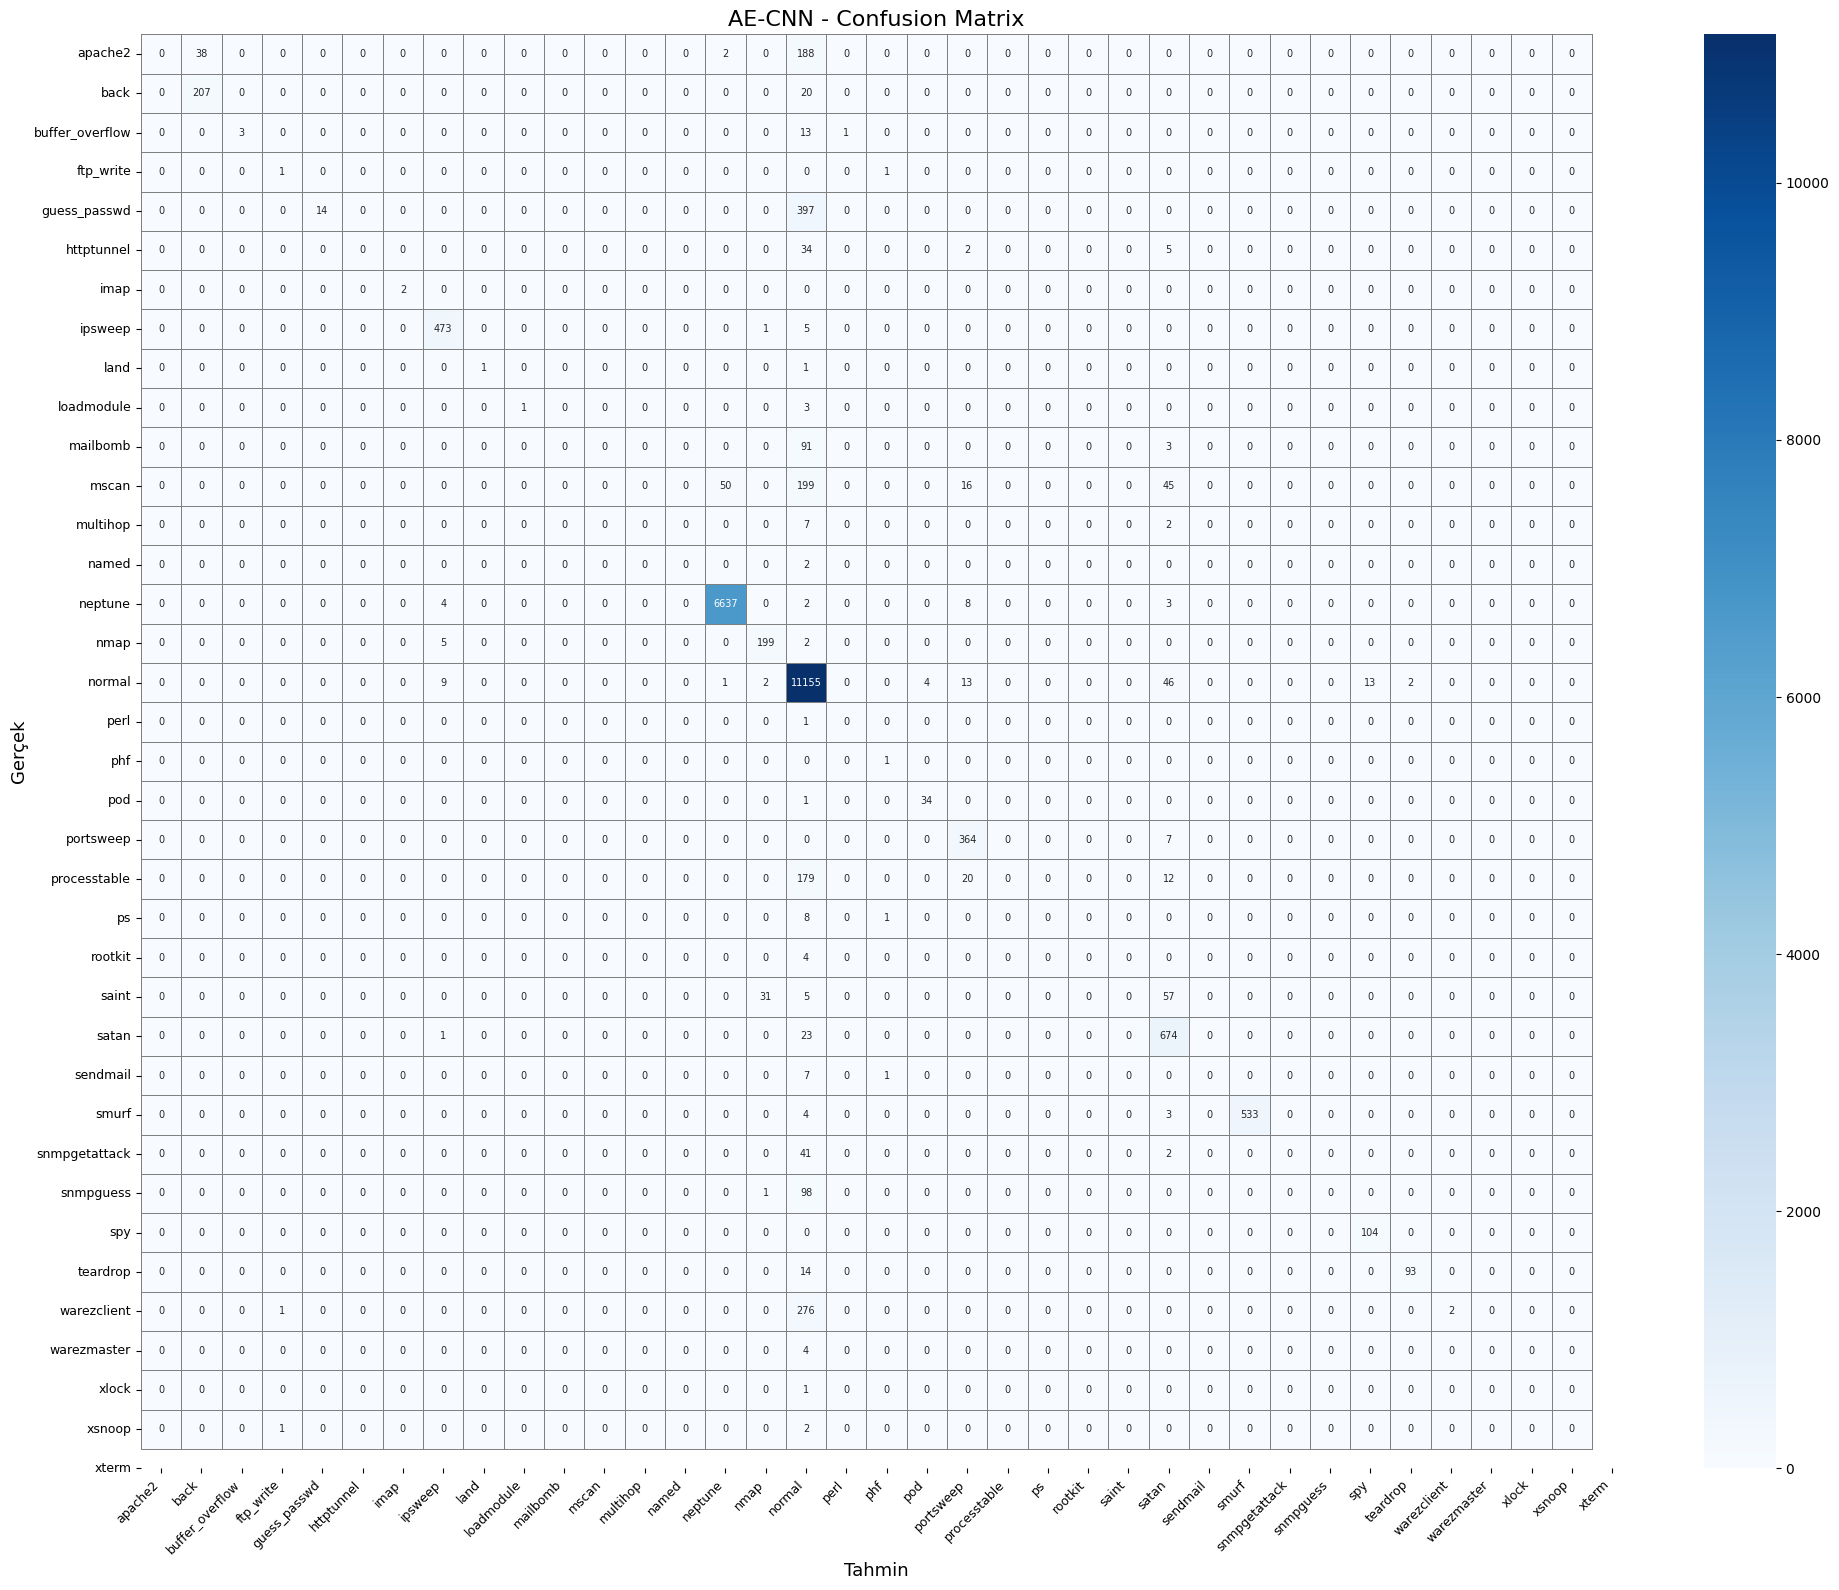

In [37]:
def plot_confusion_matrix(labels, preds, model_name, le):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"size": 7},       # Sayı font boyutu
                linewidths=0.5,               # Hücre çizgileri
                linecolor='gray')
    plt.title(f'{model_name} - Confusion Matrix', fontsize=16)
    plt.xlabel('Tahmin', fontsize=13)
    plt.ylabel('Gerçek', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cnn_labels, cnn_preds, 'CNN', le_labels)
plot_confusion_matrix(ae_cnn_labels, ae_cnn_preds, 'AE-CNN', le_labels)
